In [2]:
from sklearn.linear_model import LogisticRegression                         #Daten-Vergleichs-Algorythmus
lg = LogisticRegression(max_iter=2000, solver="saga")
from sklearn.metrics import accuracy_score                                  #Daten Übereinstimmung
import matplotlib.pyplot as plt                                             #Ziffern plotten
import numpy as np                                                          #csv umwandeln
from ipycanvas import Canvas                                                #Ziffereingabe
from ipywidgets import VBox, HBox, Button, IntText, Output, Label, Layout   #Design


In [3]:
#Daten vom csv laden

file_path = "data/ai_dataset.csv"

dataset_array = np.loadtxt(file_path, delimiter=",", ndmin=2)   #csv in array umwandeln

f_train = dataset_array[:, :-1]                 #features in separatem array speichern
l_train = dataset_array[:, -1].astype(int)      #labels in separatem array speichern

In [3]:
#Funktion um Daten zu plotten

def plotImage(pixelmap, ax = None):
    if not ax:
        ax = plt.gca()                                       #holt aktuellen Plotbereich 
    ax.set_yticks([]);ax.set_xticks([])                      #entfernt Achsenbeschriftung
    ax.imshow(np.reshape(pixelmap, (16,16)), cmap="grey")    #Zeigt Bild an und reshaped die Daten in 16x16 Felder

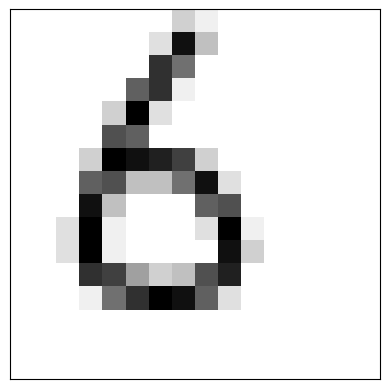

In [4]:
plotImage(f_train[0])

In [5]:
print(l_train)

[6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1]


In [8]:
count = sum(1 for x in l_train if x == 6)
print(count)

20


In [4]:
lg.fit(f_train, l_train)

/Users/jonaswigger/Documents/GitHub/.venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [5]:
def ai(input):
    input = np.array(input).reshape(1, -1)

    pred = lg.predict(input)
    prob = lg.predict_proba(input)

    confidence = np.max(prob) * 100

    return pred[0], confidence

In [6]:
#canvas (560x560 für 16x16 Raster)

#canvas-Zeichenfläche erstellen
canvas_size = 560                                                               
canvas = Canvas(width=canvas_size, height=canvas_size, sync_image_data=True)

#canvas formatieren
canvas.fill_style = 'white'
canvas.fill_rect(0, 0, 560, 560)
canvas.stroke_style = '#333'
canvas.line_cap = 'round'
canvas.line_join = 'round'
canvas.layout = Layout(width='480px', height='480px', border='2px solid black') 

#zeichnen-Status
drawing = False

#speichert vorherige Mausposition
x_prev, y_prev = 0, 0   

def on_mouse_down(x, y):
    global drawing, x_prev, y_prev
    drawing = True
    x_prev, y_prev = x, y

def on_mouse_move(x, y):
    global x_prev, y_prev
    if drawing:
        canvas.stroke_style = 'black'
        canvas.line_width = 40
        canvas.stroke_line(x_prev, y_prev, x, y)
        x_prev, y_prev = x, y

def on_mouse_up(x, y):
    global drawing
    drawing = False

#Mausevents mit functions verbinden
canvas.on_mouse_down(on_mouse_down)
canvas.on_mouse_move(on_mouse_move)
canvas.on_mouse_up(on_mouse_up)

def canvas_to_16x16():
    GRID = 16                               #Zielraster
    W, H = canvas.width, canvas.height
    cell_w, cell_h = W / GRID, H / GRID     #Zellgrössen
    
    img = canvas.get_image_data(0, 0, W, H)     #canvas-Pixel holen
    arr = np.array(img)                         #NumPy-array erstellen
    rgb = arr[..., :3].astype(np.float32)       #alpha ignorireren --> RGB
    
    gray = rgb.mean(axis=2) / 255.0     #Graustufen berechnen

    user_input = np.zeros((GRID, GRID), dtype=np.int32)  #NumPy-array für user_input erstellen

    for gy in range(GRID):                  #durch alle Zellen gehen
        for gx in range(GRID):
            y0 = int(gy * cell_h)           #Bereich der Zelle bestimmen
            y1 = int((gy + 1) * cell_h)
            x0 = int(gx * cell_w)
            x1 = int((gx + 1) * cell_w)

            patch = gray[y0:y1, x0:x1]                              #Werte dieser Zelle holen
            mean_val = patch.mean() if patch.size > 0 else 0.0      #Durchscnitt berechnen

            val = int(round(mean_val * 16))     #Werte skalieren (0-16)

            user_input[gy, gx] = val      #Wert speichern

    return user_input #.flatten()  #2D-array zu 1D-array umwandeln

#buttons
save_btn = Button(description='Ziffer erkennen', button_style='success')        #button: Speichern 
clear_btn = Button(description='Zeichnung löschen', button_style='warning')     #button: Löschen
status = Label(value='Zeichne eine Ziffer und lasse sie erkennen.')              #Statusanzeige

def clear_canvas(_):
    canvas.fill_style = 'white'
    canvas.fill_rect(0, 0, canvas.width, canvas.height)
    canvas.stroke_style = '#333'
    
    status.value = 'Canvas geleert – zeichne neu.'

def save_sample(_):
    ai_guess, ai_acc = ai(canvas_to_16x16())

    status.value = f'Die KI erkennt deine Ziffer als eine {ai_guess}. Sie ist sich zu {ai_acc:.2f}% sicher.'

save_btn.on_click(save_sample)      #buttons verbinden
clear_btn.on_click(clear_canvas)

#UI erstellen
ui = VBox([                                     
    HBox([save_btn, clear_btn]),
    status,
    canvas
])

display(ui)